<a href="https://colab.research.google.com/github/Frederik-Roeckle/GenderSentimentGermanParliament/blob/master/TrainingsloopBERT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install transformers[torch] datasets evaluate accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.3 MB/s eta 0:00:00


In [15]:
import torch
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
from transformers import pipeline
import evaluate
import numpy as np
from google.colab import drive
import pandas as pd
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, accuracy_score
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import scipy as sp
import shap

In [3]:
drive.mount('/content/drive')

# train_data = '/content/drive/MyDrive/Colab Notebooks/GermanDistilBERT/zwischenfragen_annotations.csv'
train_data = '/content/drive/MyDrive/Colab Notebooks/GermanDistilBERT/output_gender_masked.csv'

df = pd.read_csv(train_data)
# print(df.head())

Mounted at /content/drive
   Unnamed: 0    source_file  \
0           0  BT_02_064.xml   
1           1  BT_02_070.xml   
2           2  BT_02_070.xml   
3           3  BT_02_070.xml   
4           4  BT_02_070.xml   

                                  permission_request   permission_answer  \
0  Herr Abgeordneter, gestatten Sie eine Zwischen...                 Ja.   
1  Herr Abgeordneter, gestatten Sie eine Zwischen...  Gern! Bitte schön!   
2  Herr Abgeordneter, gestatten Sie eine Zwischen...        Bitte schön!   
3  Herr Abgeordneter, gestatten Sie eine Zwischen...               Gern!   
4  Gestatten Sie eine Zwischenfrage, Herr Bundesk...                 Ja!   

  permission_granted                                 zwischenfrage_text  \
0               True  Gestatten Sie, Herr Kollege Schloß, eine Frage...   
1               True  Herr Kollege Erler, gestatten Sie mir bitte ei...   
2               True  Ich weiß nicht, Herr Kollege Erler, ob ich Sie...   
3               True  He

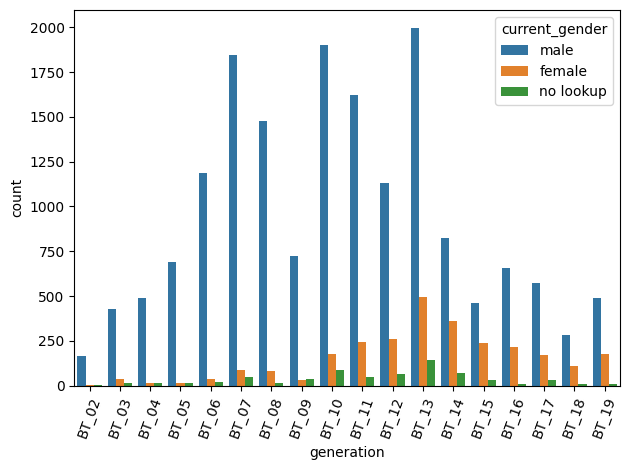

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
df["generation"] = df["source_file"].str[:5]
a = df[["generation", "current_gender"]].value_counts().to_frame().sort_values("generation")
sns.barplot(a, x="generation", y="count", hue="current_gender")

plt.xticks(rotation=70)
plt.tight_layout()

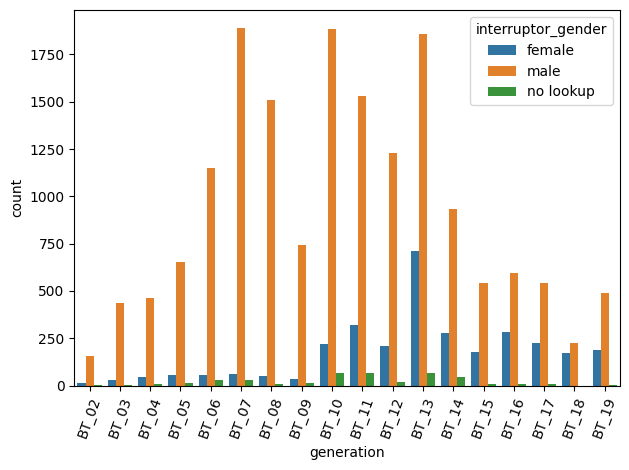

In [5]:
b = df[["generation", "interruptor_gender"]].value_counts().to_frame().sort_values("generation")
sns.barplot(b, x="generation", y="count", hue="interruptor_gender")

plt.xticks(rotation=70)
plt.tight_layout()

In [36]:
zwischenfrage = False
gender_prediction = True


if zwischenfrage:
  texts = df.zwischenfrage
  labels = df.annotation

  raw_dataset = Dataset.from_dict({"text": texts, "label": labels})
  print(raw_dataset)

  # Split into Train and Test (80/20)
  dataset_dict = raw_dataset.train_test_split(test_size=0.2)

if gender_prediction:
  df.dropna(subset=["zwischenfrage_text_masked_combined"], inplace=True)
  df = df.loc[df["current_gender"] != "no lookup"]
  df.current_gender = df.current_gender.replace("male", 0)
  df.current_gender = df.current_gender.replace("female", 1)

  # temporal split over 4 quantilles

  subset_2_5_gen = ["BT_02", "BT_03", "BT_04", "BT_05"]
  subset_6_10_gen = ["BT_06", "BT_07", "BT_08", "BT_09", "BT_10"]
  subset_11_14_gen = ["BT_11", "BT_12", "BT_13", "BT_14"]
  subset_15_19_gen = ["BT_15", "BT_16", "BT_17", "BT_18", "BT_19"]

  df_subset_2_5 = df.loc[df.generation.isin(subset_2_5_gen)]
  df_subset_6_10 = df.loc[df.generation.isin(subset_6_10_gen)]
  df_subset_11_14 = df.loc[df.generation.isin(subset_11_14_gen)]
  df_subset_15_19 = df.loc[df.generation.isin(subset_15_19_gen)]


  # Split into Train and Test (80/20)
  #
  # Shuffle Test
  # To run the shuffle test the labels of the training sets have to be permuted
  # with e.g. np.random.permutation(train_2_5.current_gender.to_list())

  # dataset split 2_5
  train_2_5, test_2_5 = train_test_split(
    df_subset_2_5[["zwischenfrage_text_masked_combined", "current_gender"]],
    test_size=0.20,
    random_state=42,
    stratify=df_subset_2_5['current_gender']
  )
  # train_2_5_ds = Dataset.from_pandas(train_2_5.reset_index(drop=True))
  train_2_5_ds = Dataset.from_dict({"text": train_2_5.zwischenfrage_text_masked_combined.to_list(),
                                    "labels": train_2_5.current_gender.to_list()})
  test_2_5_ds = Dataset.from_dict({"text": test_2_5.zwischenfrage_text_masked_combined.to_list(),
                                   "labels": test_2_5.current_gender.to_list()})
  dataset_dict_2_5 = DatasetDict({
      'train': train_2_5_ds,
      'test': test_2_5_ds
  })


  # dataset split 6_10
  train_6_10, test_6_10 = train_test_split(
    df_subset_6_10[["zwischenfrage_text_masked_combined", "current_gender"]],
    test_size=0.20,
    random_state=42,
    stratify=df_subset_6_10['current_gender']
  )
  train_6_10_ds = Dataset.from_dict({"text": train_6_10.zwischenfrage_text_masked_combined.to_list(),
                                     "labels": train_6_10.current_gender.to_list()})
  test_6_10_ds = Dataset.from_dict({"text": test_6_10.zwischenfrage_text_masked_combined.to_list(),
                                    "labels": test_6_10.current_gender.to_list()})
  dataset_dict_6_10 = DatasetDict({
      'train': train_6_10_ds,
      'test': test_6_10_ds
  })


  # dataset split 11_14
  train_11_14, test_11_14 = train_test_split(
    df_subset_11_14[["zwischenfrage_text_masked_combined", "current_gender"]],
    test_size=0.20,
    random_state=42,
    stratify=df_subset_11_14['current_gender']
  )
  train_11_14_ds = Dataset.from_dict({"text": train_11_14.zwischenfrage_text_masked_combined.to_list(),
                                      "labels": train_11_14.current_gender.to_list()})
  test_11_14_ds =  Dataset.from_dict({"text": test_11_14.zwischenfrage_text_masked_combined.to_list(),
                                      "labels": test_11_14.current_gender.to_list()})
  dataset_dict_11_14 = DatasetDict({
      'train': train_11_14_ds,
      'test': test_11_14_ds
  })


  # dataset split 15_19
  train_15_19, test_15_19 = train_test_split(
    df_subset_15_19[["zwischenfrage_text_masked_combined", "current_gender"]],
    test_size=0.20,
    random_state=42,
    stratify=df_subset_15_19['current_gender']
  )
  train_15_19_ds = Dataset.from_dict({"text": train_15_19.zwischenfrage_text_masked_combined.to_list(),
                                      "labels": train_15_19.current_gender.to_list()})
  # Attention to remove shuffle if not needed
  test_15_19_ds = Dataset.from_dict({"text": test_15_19.zwischenfrage_text_masked_combined.to_list(),
                                     "labels": test_15_19.current_gender.to_list()})
  dataset_dict_15_19 = DatasetDict({
      'train': train_15_19_ds,
      'test': test_15_19_ds
  })

In [37]:
model_name = "distilbert/distilbert-base-german-cased"
num_labels = 2

def tokenize_function(examples):
      return tokenizer(examples["text"], truncation=True, padding=True)

def compute_metrics(eval_pred):
      logits, labels = eval_pred
      # print(logits)
      predictions = np.argmax(logits, axis=-1)
      return metric.compute(predictions=predictions, references=labels, average="macro")

for name, dataset_dict in {"15_19": dataset_dict_15_19,
                           "2_5": dataset_dict_2_5,
                           "6_10": dataset_dict_6_10,
                           "11_14": dataset_dict_11_14,
                           }.items():
  print(name)
  tokenizer = AutoTokenizer.from_pretrained(model_name)
  tokenized_datasets = dataset_dict.map(tokenize_function, batched=True)
  data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

  if gender_prediction:
    id2label = {0: "male", 1: "female"}
    label2id = {"male": 0, "female": 1}

  model = AutoModelForSequenceClassification.from_pretrained(
      model_name,
      num_labels=num_labels,
      id2label=id2label,
      label2id=label2id
  )

  metric = evaluate.load("f1")

  training_args = TrainingArguments(
    output_dir=f"./german-binary-classifier_{name}_shuffle",
    learning_rate=1e-5,
    per_device_train_batch_size=64,
    num_train_epochs=10, # Slightly more epochs for smaller custom datasets
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    push_to_hub=False,
    logging_strategy="epoch",
    logging_steps=10,
  )

  trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    #tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
  )

  trainer.train()
  trainer.save_model(f"./my_custom_german_model_{name}_masked_stratified")
  trainer.save_model(f"/content/drive/MyDrive/Colab Notebooks/GermanDistilBERT/my_custom_german_model_{name}_masked_stratified")


15_19


Map:   0%|          | 0/1908 [00:00<?, ? examples/s]

Map:   0%|          | 0/478 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-german-cased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

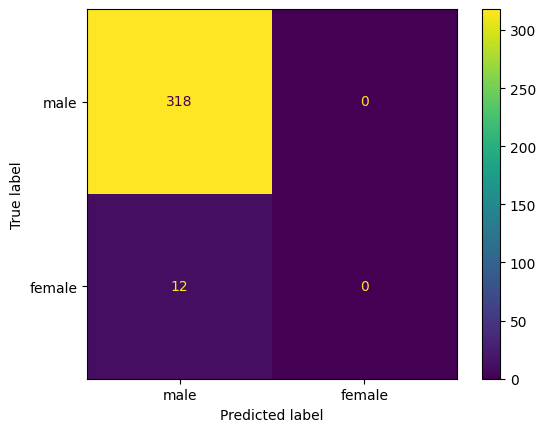

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

        male       0.96      1.00      0.98       318
      female       0.00      0.00      0.00        12

    accuracy                           0.96       330
   macro avg       0.48      0.50      0.49       330
weighted avg       0.93      0.96      0.95       330



Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

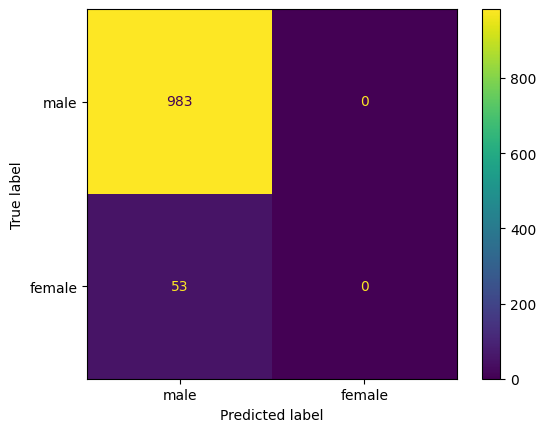

              precision    recall  f1-score   support

        male       0.95      1.00      0.97       983
      female       0.00      0.00      0.00        53

    accuracy                           0.95      1036
   macro avg       0.47      0.50      0.49      1036
weighted avg       0.90      0.95      0.92      1036



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

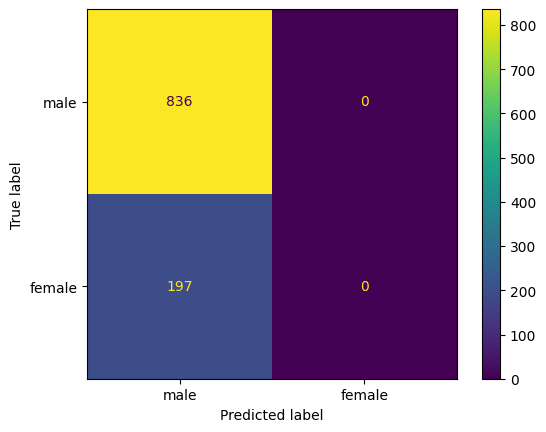

              precision    recall  f1-score   support

        male       0.81      1.00      0.89       836
      female       0.00      0.00      0.00       197

    accuracy                           0.81      1033
   macro avg       0.40      0.50      0.45      1033
weighted avg       0.65      0.81      0.72      1033



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

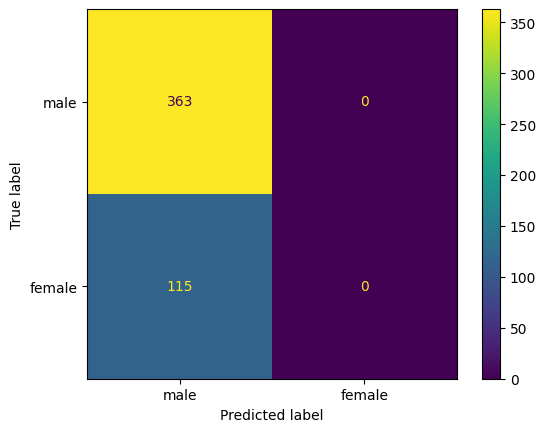

              precision    recall  f1-score   support

        male       0.76      1.00      0.86       363
      female       0.00      0.00      0.00       115

    accuracy                           0.76       478
   macro avg       0.38      0.50      0.43       478
weighted avg       0.58      0.76      0.66       478



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [39]:
# 2_5
pipe = pipeline(
    "text-classification",
    model="./my_custom_german_model_2_5_masked_stratified",
    tokenizer="./my_custom_german_model_2_5_masked_stratified"
)
X = list(dataset_dict_2_5["test"]["text"])
X = [x[:500] for x in X]
predictions = pipe.predict(X)
pred = [int(p["label"].replace("female", "1").replace("male", "0")) for p in predictions]
cm = confusion_matrix(dataset_dict_2_5["test"]["labels"], pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["male", "female"])
disp.plot()
plt.show()

print(classification_report(
    dataset_dict_2_5["test"]["labels"],
    pred,
    output_dict=False,
    target_names=['male', 'female']
))



# 6_10
pipe = pipeline(
    "text-classification",
    model="./my_custom_german_model_6_10_masked_stratified",
    tokenizer="./my_custom_german_model_6_10_masked_stratified"
)
X = list(dataset_dict_6_10["test"]["text"])
X = [x[:500] for x in X]
predictions = pipe.predict(X)
pred = [int(p["label"].replace("female", "1").replace("male", "0")) for p in predictions]
cm = confusion_matrix(dataset_dict_6_10["test"]["labels"], pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["male", "female"])
disp.plot()
plt.show()

print(classification_report(
    dataset_dict_6_10["test"]["labels"],
    pred,
    output_dict=False,
    target_names=['male', 'female']
))


# 11_14
pipe = pipeline(
    "text-classification",
    model="./my_custom_german_model_11_14_masked_stratified",
    tokenizer="./my_custom_german_model_11_14_masked_stratified"
)
X = list(dataset_dict_11_14["test"]["text"])
X = [x[:500] for x in X]
predictions = pipe.predict(X)
pred = [int(p["label"].replace("female", "1").replace("male", "0")) for p in predictions]
cm = confusion_matrix(dataset_dict_11_14["test"]["labels"], pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["male", "female"])
disp.plot()
plt.show()

print(classification_report(
    dataset_dict_11_14["test"]["labels"],
    pred,
    output_dict=False,
    target_names=['male', 'female']
))


# 15_19
pipe = pipeline(
    "text-classification",
    model="./my_custom_german_model_15_19_masked_stratified",
    tokenizer="./my_custom_german_model_15_19_masked_stratified"
)
X = list(dataset_dict_15_19["test"]["text"])
X = [x[:500] for x in X]
predictions = pipe.predict(X)
pred = [int(p["label"].replace("female", "1").replace("male", "0")) for p in predictions]
cm = confusion_matrix(dataset_dict_15_19["test"]["labels"], pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["male", "female"])
disp.plot()
plt.show()

print(classification_report(
    dataset_dict_15_19["test"]["labels"],
    pred,
    output_dict=False,
    target_names=['male', 'female']
))

Balanced 50/50 Training

In [7]:
# 50/50 Training
# Train on equal amount of male and female observations and test on actual
# distribution. Leverage BT_02 - BT_14 as train and BT_15 - BT_19 as test

subset_2_17_gen = ["BT_02", "BT_03", "BT_04", "BT_05", "BT_06", "BT_07", "BT_08", "BT_09", "BT_10", "BT_11", "BT_12", "BT_13", "BT_14","BT_15", "BT_16", "BT_17"]
subset_18_19_gen = ["BT_18", "BT_19"]

df_subset_2_17 = df.loc[df.generation.isin(subset_2_17_gen)]
df_subset_18_19 = df.loc[df.generation.isin(subset_18_19_gen)]

# sample as many male as female obs
train_female = df_subset_2_17.loc[df_subset_2_17["current_gender"] == 1]  # 1 for female
train_male = df_subset_2_17.loc[df_subset_2_17["current_gender"] == 0].sample(len(train_female), random_state=42)
train_equal = pd.concat([train_female, train_male])

# reorder to not influence further training
train_equal = train_equal.sample(frac=1)

# construct stratified test set from 18-19 on real distribution
_, test_18_19 = train_test_split(
    df_subset_18_19[["zwischenfrage_text_masked_combined", "current_gender"]],
    test_size=0.99,
    random_state=42,
    stratify=df_subset_18_19['current_gender']
)

# construct dataset

train_equal_ds = Dataset.from_dict({"text": train_equal.zwischenfrage_text_masked_combined.to_list(),
                                      "labels": train_equal.current_gender.to_list()})
test_18_19_ds =  Dataset.from_dict({"text": test_18_19.zwischenfrage_text_masked_combined.to_list(),
                                    "labels": test_18_19.current_gender.to_list()})
dataset_dict_equal = DatasetDict({
    'train': train_equal_ds,
    'test': test_18_19_ds
})



equal


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/464 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

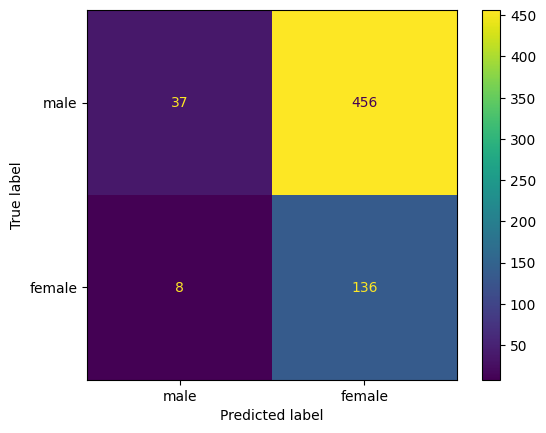

              precision    recall  f1-score   support

        male       0.82      0.08      0.14       493
      female       0.23      0.94      0.37       144

    accuracy                           0.27       637
   macro avg       0.53      0.51      0.25       637
weighted avg       0.69      0.27      0.19       637



In [8]:
only_evaluation = False
model_name = "distilbert/distilbert-base-german-cased"
num_labels = 2
name = "equal"
dataset_dict = dataset_dict_equal

def tokenize_function(examples):
      return tokenizer(examples["text"], truncation=True, padding=True)

def compute_metrics(eval_pred):
      logits, labels = eval_pred
      # print(logits)
      predictions = np.argmax(logits, axis=-1)
      return metric.compute(predictions=predictions, references=labels, average="macro")

if not only_evaluation:
  print(name)
  tokenizer = AutoTokenizer.from_pretrained(model_name)
  tokenized_datasets = dataset_dict.map(tokenize_function, batched=True)
  data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

  if gender_prediction:
    id2label = {0: "male", 1: "female"}
    label2id = {"male": 0, "female": 1}

  model = AutoModelForSequenceClassification.from_pretrained(
      model_name,
      num_labels=num_labels,
      id2label=id2label,
      label2id=label2id
  )

  metric = evaluate.load("f1")

  training_args = TrainingArguments(
    output_dir=f"./german-binary-classifier_{name}_shuffle",
    learning_rate=1e-5,
    per_device_train_batch_size=64,
    num_train_epochs=10, # Slightly more epochs for smaller custom datasets
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    push_to_hub=False,
    logging_strategy="epoch",
    logging_steps=10,
  )

  trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    #tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
  )

  trainer.train()
  trainer.save_model(f"./my_custom_german_model_{name}_shuffle")


# Evaluation
pipe = pipeline(
    "text-classification",
    model=f"./my_custom_german_model_{name}_shuffle",
    tokenizer=f"./my_custom_german_model_{name}_shuffle"
)
X = list(dataset_dict["test"]["text"])
X = [x[:500] for x in X]
predictions = pipe.predict(X)
pred = [int(p["label"].replace("female", "1").replace("male", "0")) for p in predictions]
cm = confusion_matrix(dataset_dict["test"]["labels"], pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["male", "female"])
disp.plot()
plt.show()

print(classification_report(
    dataset_dict["test"]["labels"],
    pred,
    output_dict=False,
    target_names=['male', 'female']
))

In [34]:
# load a BERT sentiment analysis model
#tokenizer = transformers.DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")
#model = transformers.DistilBertForSequenceClassification.from_pretrained(
#    "distilbert-base-uncased-finetuned-sst-2-english"
#).cuda()


# define a prediction function
def f(x):
    tv = torch.tensor([pipe.tokenizer.encode(v, padding="max_length", max_length=500, truncation=True) for v in x]).cuda()
    outputs = model(tv)[0].detach().cpu().numpy()
    scores = (np.exp(outputs).T / np.exp(outputs).sum(-1)).T
    val = sp.special.logit(scores[:, 1])  # use one vs rest logit units
    return val


# build an explainer using a token masker
explainer = shap.Explainer(f, pipe.tokenizer)

# explain the model's predictions on IMDB reviews
shap_values = explainer(dataset_dict["test"][:10], fixed_context=1)

  0%|          | 0/498 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 4it [00:23,  2.20s/it]               

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 5it [00:33,  5.54s/it]

...

PartitionExplainer explainer: 6it [00:42,  6.54s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 8it [00:53,  5.91s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 11it [01:10,  7.79s/it]


In [35]:
shap.plots.text(shap_values[:2, :100])
#shap.plots.waterfall(shap_values[0])


#shap.plots.bar(shap_values.abs.max(0))
#shap.plots.bar(shap_values)
#shap.plots.text(shap_values)
#shap.plots.text(shap_values[:1, :55])

# Single Runs

In [ ]:
model_name = "distilbert/distilbert-base-german-cased"
num_labels = 2

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, padding=True)

tokenized_datasets = dataset_dict.map(tokenize_function, batched=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Map:   0%|          | 0/1317 [00:00<?, ? examples/s]

KeyError: 'text'

In [ ]:

if zwischenfrage:
  id2label = {0: "NEGATIVE", 1: "POSITIVE"}
  label2id = {"NEGATIVE": 0, "POSITIVE": 1}

  model = AutoModelForSequenceClassification.from_pretrained(
      model_name,
      num_labels=num_labels,
      id2label=id2label,
      label2id=label2id
  )
  for param in model.distilbert.parameters():
      param.requires_grad = False


if gender_prediction:
  id2label = {0: "male", 1: "female"}
  label2id = {"male": 0, "female": 1}

  model = AutoModelForSequenceClassification.from_pretrained(
      model_name,
      num_labels=num_labels,
      id2label=id2label,
      label2id=label2id
  )
  # no freezing loops of weights

model.safetensors:   0%|          | 0.00/270M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-german-cased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
metric = evaluate.load("f1") # F1-score is often better for binary tasks

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

In [ ]:
training_args = TrainingArguments(
    output_dir="./german-binary-classifier",
    learning_rate=1e-5,
    per_device_train_batch_size=64,
    num_train_epochs=10, # Slightly more epochs for smaller custom datasets
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    push_to_hub=False,
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    #tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

In [ ]:
trainer.train()
trainer.save_model("./my_custom_german_model")

Epoch,Training Loss,Validation Loss,F1
1,No log,0.364753,0.000000
2,No log,0.358245,0.005464
3,0.367117,0.357520,0.086735
4,0.367117,0.363010,0.121065
5,0.367117,0.370297,0.227799
6,0.310960,0.379311,0.257812
7,0.310960,0.388094,0.261649
8,0.310960,0.399279,0.272572
9,0.255966,0.411544,0.282642
10,0.255966,0.409132,0.267559


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
# Inference Test

pipe = pipeline(
    "text-classification",
    model="./my_custom_german_model",
    tokenizer="./my_custom_german_model"
)

# 2. Predict on a single sentence
text = "Ich nehme die Zwischenfrage gerne an."
result = pipe(text)
print(f"Result: {result}")

# 3. Predict on a list of sentences
sequences = [
    "Dafür habe ich nun leider keine Zeit.",
    "Noch nicht.",
    "Beim nächsten Mal.",
    "Ja, sehr gerne Frau Kollegin."
]
results = pipe(sequences)

for text, res in zip(sequences, results):
    print(f"\nText: {text}")
    print(f"Label: {res['label']}, Score: {res['score']:.4f}")

OSError: Repo id must use alphanumeric chars, '-', '_' or '.'. The name cannot start or end with '-' or '.' and the maximum length is 96: './my_custom_german_model'.

## TF-IDF approach

In [ ]:
for name, dataset_dict in {"2_5": dataset_dict_2_5, "6_10": dataset_dict_6_10, "11_14": dataset_dict_11_14, "15_19": dataset_dict_15_19}.items():
  text_clf = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),   # Look at single words AND pairs (e.g., "nicht gut")
        max_features=1000,    # Limit features so we don't overfit
        stop_words=None       # We'll handle German stops below or keep them
    )),
    ('clf', LogisticRegression(C=1.0)), # C is regularization; lower C = less overfitting
  ])

  # 4. Train
  text_clf.fit(dataset_dict["train"]["text"], dataset_dict["train"]["labels"])

  # 5. Evaluate
  predictions = text_clf.predict(dataset_dict["test"]["text"])
  print(f"Accuracy: {accuracy_score(dataset_dict["test"]["labels"], predictions):.2%}")
  print(classification_report(dataset_dict["test"]["labels"], predictions))

  # 6. Save the model
  joblib.dump(text_clf, 'german_tfidf_model.pkl')


Accuracy: 96.67%
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       318
           1       1.00      0.08      0.15        12

    accuracy                           0.97       330
   macro avg       0.98      0.54      0.57       330
weighted avg       0.97      0.97      0.95       330

Accuracy: 97.20%
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       983
           1       0.93      0.49      0.64        53

    accuracy                           0.97      1036
   macro avg       0.95      0.74      0.81      1036
weighted avg       0.97      0.97      0.97      1036

Accuracy: 95.55%
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       836
           1       0.97      0.79      0.87       197

    accuracy                           0.96      1033
   macro avg       0.96      0.89      0.92      1033
weighted avg       0.96

In [ ]:

# 2. Split the data
X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)

# 3. Create the Pipeline
# We use German stop words because common words like "der, die, das"
# carry no meaning for classification.
text_clf = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),   # Look at single words AND pairs (e.g., "nicht gut")
        max_features=1000,    # Limit features so we don't overfit
        stop_words=None       # We'll handle German stops below or keep them
    )),
    ('clf', LogisticRegression(C=1.0)), # C is regularization; lower C = less overfitting
])

# 4. Train
text_clf.fit(X_train, y_train)

# 5. Evaluate
predictions = text_clf.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, predictions):.2%}")
print(classification_report(y_test, predictions))

# 6. Save the model
joblib.dump(text_clf, 'german_tfidf_model.pkl')

Accuracy: 86.82%
              precision    recall  f1-score   support

           0       0.87      1.00      0.93      2499
           1       0.00      0.00      0.00       377

    accuracy                           0.87      2876
   macro avg       0.43      0.50      0.46      2876
weighted avg       0.75      0.87      0.81      2876



['german_tfidf_model.pkl']

In [ ]:
# For Inference
import joblib

# Load the model
model = joblib.load('german_tfidf_model.pkl')

# Predict
new_texts = [
    "Dafür habe ich nun leider keine Zeit.",
    "Noch nicht.",
    "Nein, Beim nächsten Mal.",
    "Ja, oder nein, nein!.",
    "Bitte, Herr Kollege",
    "An Sie, Frau Kollegin. Familie, Frauen, Erziehung, Haushalt, Geburt, Emotional, Weiblich, schwach"
]
preds = model.predict(new_texts)
probs = model.predict_proba(new_texts) # Returns probability for [Class 0, Class 1]

for text, p, prob in zip(new_texts, preds, probs):
    print(f"Text: {text} | Label: {p} | Confidence: {max(prob):.2%}")

Text: Dafür habe ich nun leider keine Zeit. | Label: 0 | Confidence: 88.80%
Text: Noch nicht. | Label: 0 | Confidence: 87.84%
Text: Nein, Beim nächsten Mal. | Label: 0 | Confidence: 92.79%
Text: Ja, oder nein, nein!. | Label: 0 | Confidence: 87.18%
Text: Bitte, Herr Kollege | Label: 0 | Confidence: 80.66%
Text: An Sie, Frau Kollegin. Familie, Frauen, Erziehung, Haushalt, Geburt, Emotional, Weiblich, schwach | Label: 0 | Confidence: 50.07%
